### Imports

In [20]:
import torch
import scipy.io
import mne
import sklearn
import os 
import random
import scipy.linalg
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import numpy as np
import lightgbm as lgb

from itertools import chain, product

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from mne_features.feature_extraction import FeatureExtractor
from torch.utils.data import random_split, DataLoader, Dataset
from torch.nn import functional as F
from torch import nn
from pytorch_lightning.core.module import LightningModule
from pytorch_lightning.loggers import TensorBoardLogger
from scipy.stats import norm, wasserstein_distance


In [21]:
# Assess whether GPU is availble
if torch.cuda.is_available():
    print("PyTorch is using the GPU.")
    print("Device name - ", torch.cuda.get_device_name(torch.cuda.current_device()))
else: 
    print("PyTorch is not using the GPU.")
    

PyTorch is using the GPU.
Device name -  NVIDIA GeForce RTX 3080


In [22]:
# Import Utility functions frmo diffrent notebooks
import import_ipynb
from IEEE_data import extract_ieee_data, LazyProperty, data_4class
from CHIST_ERA_data import *
from Utils import *

### Helper Functions

In [23]:
def eegFilters(eegMat, fs, filterLim):
    eegMatFiltered = mne.filter.filter_data(eegMat, fs, filterLim[0], filterLim[1], verbose=0)
    return eegMatFiltered

In [24]:
def mneFeatures(X, fs):
    selected_funcs = ['line_length', 'kurtosis', 'skewness', 'pow_freq_bands', 'spect_slope',
                     'spect_entropy', 'spect_edge_freq', 'mean', 'variance', 'ptp_amp']
    params = {'pow_freq_bands__freq_bands' : np.array([[8, 10],
                                                      [10,12],
                                                      [9, 13],
                                                      [12, 20],
                                                      [20, 25],
                                                      [25, 30]])}
    fe = FeatureExtractor(sfreq=fs, selected_funcs=selected_funcs, params=params)

    X_features = fe.fit_transform(X)
    return X_features

In [25]:
def convert2csp(signal, labels, n_components):
    
    # Set verbose to 0
    mne.set_log_level(verbose='WARNING', return_old_level=False, add_frames=None)

    # create csp object
    csp = mne.decoding.CSP(n_components=n_components, reg=None, log=None, norm_trace=False, transform_into='csp_space')
    # transofrm the signal
    csp.fit(signal, labels)
    csp_signal = csp.transform(signal)
    return csp_signal

In [26]:
def plotSignal(elec, model, dataLoader):
    # Create iterable object
    data_iter = iter(dataLoader)
    data, _ = data_iter.next()

    
    # Reconstruct data using given model
    recon_data = model(data).detach()
    
    
    # Plot original and reconstructed data
    plt.figure(1)
    plt.plot(data[0, elec, :], zorder=1)
    plt.plot(recon_data[0, elec, :], zorder=0)
    plt.legend(['Original', 'Reconstructed'])
    plt.title(f'mse-Loss: {F.mse_loss(recon_data[0, elec, :], data[0, elec, :])}')
    plt.xlabel('Time [mS]')
    plt.ylabel('μV')

    plt.figure(2)
    plt.plot(data[0, elec, :] - recon_data[0, elec, :])
    plt.legend(['Residulas'])
    plt.title(f'Residuals Signal')
    plt.xlabel('Time [mS]')
    plt.ylabel('μV')

    
    plt.show()

In [27]:
def pca_error(W, x):
    x = torch.reshape(x, (x.shape[1], x.shape[0] * x.shape[2])).T
    pc = torch.matmul(x, W)
    x_rec = torch.matmul(pc, W.T)
    error = torch.norm(x - x_rec)
    return error

In [28]:
def mne_classifier(signal, labels, fs, zero_time, classifier = False):
    # cut signal before + after
    signal_before = signal[:, :, :fs*zero_time]
    signal_after = signal[:, :, fs*zero_time:]
    # Get features
    features_before = mneFeatures(signal_before, fs)
    features_after = mneFeatures(signal_after, fs)
    
#     X = np.hstack((features_before, features_after))
    X = np.divide(features_before, features_after)
    if classifier:
        score = features_classfier(X, labels, 5, classifier)
        return score
    else:
        score, clf = features_classfier(X, labels, 5, classifier)
    return score, clf


In [29]:
def features_classfier(X, y, cv_N = 5, classifier = False):
    
    scores = []
    
    if classifier:
        y_pred = classifier.predict(X)
        acc = sklearn.metrics.accuracy_score(y, y_pred)
        return acc
    
    else:
        # Assemble a classifier
#         clf = RandomForestClassifier()
        clf = lgb.LGBMClassifier(learning_rate=0.09,max_depth=-5,random_state=42)
        scores = cross_val_score(clf, X, y, cv=cv_N, n_jobs=1)
        clf.fit(X, y)
        return np.mean(scores), clf

In [30]:
def original_day_classifier(eeg_list):
    # Use day zero classifier for classifying the reconstructed eeg per day
    
    residuals = []
    labels = []
    for day_i in range(len(eeg_list)):
        # Get data
        signal_test_data = EEGDataSet_signal(dictListStacked, [day_i, day_i+1])
        signal_test, y_test = signal_test_data.getAllItems()
       
        # Get residuals
        residuals.append(signal_test.detach().numpy())
        labels.append(np.ones((1, signal_test.shape[0])) * day_i)
    labels= np.hstack(labels)
    labels = np.squeeze(labels)
    residuals = np.vstack(residuals)

    score, _ = csp_score(np.float64(residuals), labels, cv_N = 5, classifier = False)
    return score

In [31]:
def reconstruction_day_classifier(AE_model, eeg_list):
    # Use day zero classifier for classifying the reconstructed eeg per day
    
    residuals = []
    labels = []
    for day_i in range(len(eeg_list)):
        # Get data
        signal_test_data = EEGDataSet_signal(dictListStacked, [day_i, day_i+1])
        signal_test, y_test = signal_test_data.getAllItems()

        # reconstruct EEG AE
        rec_signal = AE_model(signal_test).detach().numpy()        
        # Get residuals
        residuals.append(rec_signal)
        labels.append(np.ones((1, signal_test.shape[0])) * day_i)
    labels= np.hstack(labels)
    labels = np.squeeze(labels)
    residuals = np.vstack(residuals)

    score, _ = csp_score(np.float64(residuals), labels, cv_N = 5, classifier = False)
    return score

In [32]:
def residual_day_classifier(AE_model, eeg_list):
    # Use day zero classifier for classifying the residuals per day
    
    residuals = []
    labels = []
    for day_i in range(len(eeg_list)):
        # Get data
        signal_test_data = EEGDataSet_signal(dictListStacked, [day_i, day_i+1])
        signal_test, y_test = signal_test_data.getAllItems()

        # reconstruct EEG AE
        rec_signal = AE_model(signal_test).detach().numpy()        
        # Get residuals
        residuals.append((signal_test - rec_signal).detach().numpy())
        labels.append(np.ones((1, signal_test.shape[0])) * day_i)
    labels= np.hstack(labels)
    labels = np.squeeze(labels)
    residuals = np.vstack(residuals)

    score, _ = csp_score(np.float64(residuals), labels, cv_N = 5, classifier = False)
    return score

### Datset and Model classes

In [33]:
class EEGDataSet_signal(Dataset):
    def __init__(self, EEGDict, days_range=[0,1]):
        
        # Concat dict      
        X, y = self.concat(EEGDict, days_range)
        

        
        # Convert from numpy to tensor
        self.X = torch.tensor(X)
        self.n_samples = self.X.shape[0]
        self.n_channels = self.X.shape[1]
        self.y = y

        
    def __getitem__(self, index):
        return self.X[index].float(), self.y[index]
    
    def __len__(self):
        return self.n_samples
    
    def getAllItems(self):
        return self.X.float() , self.y
    
    def concat(self, EEGDict, days_range):
        X = []
        y = []
        for d in dictListStacked[days_range[0]:days_range[1]]:
            X.append(d['segmentedEEG'])
            y.append(d['labels'])

        X = np.asarray(X)
        y = np.asarray(y)
        X = np.concatenate(X)
        y = np.concatenate(y)
        return X, y

In [34]:
class convolution_AE(LightningModule):
    def __init__(self, input_channels, learning_rate=1e-3, filters_n = [16, 32, 64], pca_W = False):
        super().__init__()
        self.input_channels = input_channels
        self.filters_n = filters_n
        self.learning_rate = learning_rate
        self.float()
        self.l1_filters, self.l2_filters, self.l3_filters = self.filters_n

        self.pca_W = pca_W
        ### The model architecture ###
        
        # Encoder
        self.encoder = nn.Sequential(
        nn.Conv1d(self.input_channels, self.l1_filters, kernel_size=15, stride=2, padding=1),
        nn.LeakyReLU(),
        nn.Conv1d(self.l1_filters, self.l2_filters, kernel_size=10, stride=2, padding=1),
        nn.LeakyReLU(),
        nn.Conv1d(self.l2_filters, self.l3_filters, kernel_size=5, stride=2, padding=1),
        nn.LeakyReLU()
        )
                
        # Decoder
        self.decoder = nn.Sequential(
        # IMPORTENT - on the IEEE dataset - the output padding needs to be 1 in the row below -on CHIST-ERA its 1
        nn.ConvTranspose1d(self.l3_filters, self.l2_filters, kernel_size=5, stride=2, padding=1, output_padding=1),
        nn.LeakyReLU(),
        nn.ConvTranspose1d(self.l2_filters, self.l1_filters, kernel_size=10, stride=2, padding=1, output_padding=0),
        nn.LeakyReLU(),
        nn.ConvTranspose1d(self.l1_filters, self.input_channels, kernel_size=15, stride=2, padding=1, output_padding=1),
        )

    def forward(self, x):
        # Forward through the layeres
        # Encoder
        x = self.encoder(x)

        # Decoder
        x = self.decoder(x)
        return x
    
    def encode(self, x):
        # Forward through the layeres
        # Encoder
        x = self.encoder(x)
        return x
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        # Recountruction
        logits = self.forward(x)
        # Loss function
        try:
            if len(self.pca_W.shape)>0:
                rec_error = pca_error(self.pca_W, logits)
                loss = F.mse_loss(logits, x) + 0*rec_error
        except:
            loss = F.mse_loss(logits, x)
            
        return loss
    
        
    def configure_optimizers(self):
        # Optimizer
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

## Parameters

channels names:
['FC3', 'C1', 'C3', 'C5', 'CP3', 'O1', 'FC4', 'C2', 'C4', 'C6', 'CP4']

In [42]:
subID = '201' # As str 201, 205, 206
eyesFlag = 'CC' # str        CC --> closed,   OO --> open
dataDir = 'data'

# To get all The days in subject 201:
dayNumber = get_all_days(dataDir, subID, eyesFlag) # Array of the desired days number
dayNumber.sort()
# For subject 205 & 206 its better to insert range
# dayNumber = range(1,9)

# Subject 201 has only 1 block
block = [1]
trialLen = 6 # In seconds
filterLim = [4,40] # In Hz
elec_idxs = range(11) # 0-10 according to channel names
train_days=[0,10]



ae_learning_rt = 1e-3
n_epochs = 500
batch_sz = 16
# If you want to use comparison rate - set layers_sz = False
convolution_filters = [8,16,32] # Length = 3

In [36]:
# Convert relative path to absolute path
dataDir = os.path.abspath(dataDir)


### Load the files - CHIST ERA

In [37]:
# Load all relevant days files into list
dataList = getRecording(dataDir, subID, eyesFlag, dayNumber, block)

# Extract and segment all the data
dictList = []
for dayData in dataList:
    # Extract each day data
    interData = extractData(dayData)
    
    # This condition is to remove some corrupted files in subject 201
    if interData['EEG'].dtype != np.dtype('float64'):
        continue
        
    # Filter the data
    interData['EEG'] = eegFilters(interData['EEG'], interData['fs'], filterLim)
    interData['EEG'] = interData['EEG'][elec_idxs, :]

    # Segment the data
    dictList.append(segmentEEG(interData, trialLen, printFlag=0))

# Stack block of same day
dictListStacked = stackBlocks(dictList, len(block))


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with

[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    0.

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with

[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    0.

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with

# Training loop function

In [40]:
def training_loop(train_days, dictListStacked, fs, ae_learning_rt, convolution_filters, batch_sz, epoch_n):
    

    # Logger
    logger = TensorBoardLogger('tb_logs', name='EEG_Logger')

    # Train Dataset
    signal_data = EEGDataSet_signal(dictListStacked, train_days)
    signal_data_loader = DataLoader(dataset=signal_data, batch_size=batch_sz, shuffle=True, num_workers=0)
    x, y = signal_data.getAllItems()

    # Train model on training day
    day_zero_AE = convolution_AE(signal_data.n_channels, ae_learning_rt, filters_n=convolution_filters)
    trainer_1 =  pl.Trainer(max_epochs=epoch_n, logger=logger, accelerator='gpu', devices=-1)
    trainer_1.fit(day_zero_AE, train_dataloaders=signal_data_loader)
    
       
    score_ae, day_zero_AE_clf = fbcsp_score(np.float64(day_zero_AE(x).detach().numpy()), y, cv_N=5, classifier=False, fs=fs, m_filters=11)
    score_bench, day_zero_bench_clf = fbcsp_score(np.float64(x.detach().numpy()), y, cv_N=5, classifier=False, fs=fs, m_filters=11)

    # Loop :)
    bench_diff_day_score = []
    bench_same_day_score = []
    AE_diff_day_score = []
    
    # Append day zero score
    bench_diff_day_score.append(score_bench)
    bench_same_day_score.append(score_bench)
    AE_diff_day_score.append(score_ae)

    for i in range(train_days[1], len(dictListStacked)):
        test_days = [i, i+1]

        # Create test Datasets
        signal_test_data = EEGDataSet_signal(dictListStacked, test_days)
        signal_test_data_loader = DataLoader(dataset=signal_test_data, batch_size=8, shuffle=True, num_workers=0)

        # get data
        signal_test, y_test = signal_test_data.getAllItems()
        # reconstruct EEG using day 0 AE
        rec_signal_zero = day_zero_AE(signal_test).detach().numpy()


        # Use models
        print('Day #',i)
        same_day_score, _ = fbcsp_score(np.float64(signal_test.detach().numpy()), y_test, cv_N=5, classifier=False, fs=fs, m_filters=11)
        print('Bench-\nIn day accuracy: ', same_day_score)
        bench_diff_day = fbcsp_score(np.float64(signal_test.detach().numpy()), y_test, cv_N=5, classifier=day_zero_bench_clf, fs=fs, m_filters=11)
        print('Different day accuracy: ',bench_diff_day)

        AE_diff_day = fbcsp_score(rec_signal_zero, y_test, cv_N=5, classifier=day_zero_AE_clf, fs=fs, m_filters=11)
        print('AE-\nDifferent day accuracy: ', AE_diff_day, '\n')

        # Append each day results
        AE_diff_day_score.append(AE_diff_day)
        bench_diff_day_score.append(bench_diff_day) 
        bench_same_day_score.append(same_day_score)
    
    return bench_same_day_score, bench_diff_day_score, AE_diff_day_score, day_zero_AE

In [41]:
# Sub 206 - 200 epochs
train_days=[0,10]

bench_same_day_score, bench_diff_day_score, AE_diff_day_score, day_zero_AE = \
training_loop(train_days, dictListStacked, dictListStacked[1]['fs'], ae_learning_rt, convolution_filters, batch_sz, n_epochs)


C:\Users\owner\AppData\Local\Temp\ipykernel_8208\711014022.py:32: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.asarray(X)
C:\Users\owner\AppData\Local\Temp\ipykernel_8208\711014022.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  y = np.asarray(y)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params
---------------------------------------
0 | encoder | Sequential | 

Epoch 119:  64%|███████████████████████████████▏                 | 7/11 [00:00<00:00, 132.05it/s, loss=6.84, v_num=126]

C:\Users\owner\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\trainer\call.py:48: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

# Training for several days loop function

In [48]:
def score_over_number_of_days(start_day, epoch_N, dictListStacked, fs, ae_learning_rt, \
                              convolution_filters, batch_sz, max_delta=999):
    bench_diff_day_score_mean = []
    AE_diff_day_score_mean = []
    bench_same_day_score_mean = []
    bench_diff_day_score_ste = []
    AE_diff_day_score_ste = []
    
    for delta in range(1, len(dictListStacked) - start_day):
        
        if delta > max_delta:
            break
        
        train_days=[start_day, start_day + delta]

        # Logger
        logger = TensorBoardLogger('tb_logs', name='EEG_Logger')

        # Train Dataset
        signal_data = EEGDataSet_signal(dictListStacked, train_days)
        signal_data_loader = DataLoader(dataset=signal_data, batch_size=batch_sz, shuffle=True, num_workers=0)
        x, y = signal_data.getAllItems()

        # Train model on training day
        day_zero_AE = convolution_AE(signal_data.n_channels, ae_learning_rt, filters_n=convolution_filters)
        trainer_1 =  pl.Trainer(max_epochs=epoch_N, logger=logger, accelerator='gpu', devices=-1)
        trainer_1.fit(day_zero_AE, train_dataloaders=signal_data_loader)

        # Day 0 classifier
        _, day_zero_bench_clf = fbcsp_score(np.float64(x.detach().numpy()), y, cv_N = 5, classifier = False, fs=fs, m_filters=11)
        _, day_zero_AE_clf = fbcsp_score(np.float64(day_zero_AE(x).detach().numpy()), y, cv_N = 5, classifier = False, fs=fs, m_filters=11)

        # Loop :)
        AE_diff_day_score = []
        bench_diff_day_score = [] 
        for i in range(train_days[1], len(dictListStacked)):
            test_days = [i, i+1]

            # Create test Datasets
            signal_test_data = EEGDataSet_signal(dictListStacked, test_days)
            signal_test_data_loader = DataLoader(dataset=signal_test_data, batch_size=8, shuffle=True, num_workers=0)

            # get data
            signal_test, y_test = signal_test_data.getAllItems()

            # reconstruct EEG using day 0 AE
            rec_signal_zero = day_zero_AE(signal_test).detach().numpy()


            # Use models
            bench_diff_day = fbcsp_score(np.float64(signal_test.detach().numpy()), y_test, cv_N = 5, classifier = day_zero_bench_clf, fs=fs, m_filters=11)
            AE_diff_day = fbcsp_score(np.float64(rec_signal_zero), y_test, cv_N = 5, classifier = day_zero_AE_clf, fs=fs, m_filters=11)
            
            # Save results
            AE_diff_day_score.append(AE_diff_day)
            bench_diff_day_score.append(bench_diff_day) 
        
        # Rest of the days cross validation score
        rest_data = EEGDataSet_signal(dictListStacked, [train_days[1], len(dictListStacked)])
        rest_x, rest_y = rest_data.getAllItems()
        score_bench, _= fbcsp_score(np.float64(rest_x.detach().numpy()), rest_y, cv_N = 5, classifier = False, fs=fs, m_filters=11)
        
        # Append means
        bench_diff_day_score_mean.append(np.mean(bench_diff_day_score))
        AE_diff_day_score_mean.append(np.mean(AE_diff_day_score))
        bench_same_day_score_mean.append(score_bench)
        bench_diff_day_score_ste.append(np.std(bench_diff_day_score) / np.sqrt(len(bench_diff_day_score)))
        AE_diff_day_score_ste.append(np.std(AE_diff_day_score) / np.sqrt(len(AE_diff_day_score)))
       
    # Convert results to numpy
    bench_same_day_score_mean = np.asarray(bench_same_day_score_mean)
    bench_diff_day_score_mean = np.asarray(bench_diff_day_score_mean)
    AE_diff_day_score_mean = np.asarray(AE_diff_day_score_mean)
    bench_diff_day_score_ste = np.asarray(bench_diff_day_score_ste)
    AE_diff_day_score_ste = np.asarray(AE_diff_day_score_ste)
    
    # Return results
    return bench_same_day_score_mean, bench_diff_day_score_mean, AE_diff_day_score_mean,\
            bench_diff_day_score_ste, AE_diff_day_score_ste

In [46]:
# Start from which day to plot?
plot_from = 1

# Plot
plt.plot(range(plot_from, plot_from + len(AE_diff_day_score[plot_from:])), AE_diff_day_score[plot_from:], label='AE diff day', color='g')
plt.plot(range(plot_from, plot_from + len(AE_diff_day_score[plot_from:])), bench_diff_day_score[plot_from:], label='bench diff day', color='r')
plt.plot(range(plot_from, plot_from + len(AE_diff_day_score[plot_from:])), bench_same_day_score[plot_from:], label='bench same day', color='b')

plt.axhline(y=np.mean(AE_diff_day_score[plot_from:]), color='g', linestyle='--')
plt.axhline(y=np.mean(bench_diff_day_score[plot_from:]), color='r', linestyle='--')
plt.axhline(y=np.mean(bench_same_day_score[plot_from:]), color='b', linestyle='--')

plt.title('Accuracy Over Days - Using Day 0 Classifier')
plt.xlabel('Day #')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

NameError: name 'AE_diff_day_score' is not defined

In [ ]:
res_score = residual_day_classifier(day_zero_AE, dictListStacked)
rec_score = reconstruction_day_classifier(day_zero_AE, dictListStacked)
orig_score = original_day_classifier(dictListStacked)

print('Residuals Day Classify Accuracy: ', res_score)
print('Reconstruction Day Classify Accuracy: ', rec_score)
print('Original Day Classify Accuracy: ', orig_score)

In [ ]:
signal_data = EEGDataSet_signal(dictListStacked, [3,4])
signal_data_loader = DataLoader(dataset=signal_data, batch_size=batch_sz, shuffle=True, num_workers=0)
plotSignal(0, day_zero_AE, signal_data_loader)

## Several days realizations (long time)

In [50]:
bench_same_day_score_mean, bench_diff_day_score_mean, AE_diff_day_score_mean,\
bench_std, AE_std = \
score_over_number_of_days(0, 1000, dictListStacked, 128, ae_learning_rt,\
                          convolution_filters, batch_sz, max_delta=100)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params
---------------------------------------
0 | encoder | Sequential | 5.2 K 
1 | decoder | Sequential | 5.2 K 
---------------------------------------
10.4 K    Trainable params
0         Non-trainable params
10.4 K    Total params
0.042     Total estimated model params size (MB)
C:\Users\owner\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
C:\Users\owner\AppData\Local\Programs\Python\Python310\lib\site-packag

Epoch 999: 100%|███████████████████████████████████████████████████| 2/2 [00:00<00:00, 105.24it/s, loss=3.9, v_num=128]

`Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 999: 100%|████████████████████████████████████████████████████| 2/2 [00:00<00:00, 83.31it/s, loss=3.9, v_num=128]


C:\Users\owner\AppData\Local\Temp\ipykernel_8208\711014022.py:32: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.asarray(X)
C:\Users\owner\AppData\Local\Temp\ipykernel_8208\711014022.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  y = np.asarray(y)
C:\Users\owner\AppData\Local\Temp\ipykernel_8208\711014022.py:32: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype

...

C:\Users\owner\AppData\Local\Temp\ipykernel_8208\711014022.py:32: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.asarray(X)
C:\Users\owner\AppData\Local\Temp\ipykernel_8208\711014022.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  y = np.asarray(y)
C:\Users\owner\AppData\Local\Temp\ipykernel_8208\711014022.py:32: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype

Epoch 999: 100%|██████████████████████████████████████████████| 107/107 [00:00<00:00, 147.94it/s, loss=8.65, v_num=227]

`Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 999: 100%|██████████████████████████████████████████████| 107/107 [00:00<00:00, 145.03it/s, loss=8.65, v_num=227]


C:\Users\owner\AppData\Local\Temp\ipykernel_8208\711014022.py:32: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.asarray(X)
C:\Users\owner\AppData\Local\Temp\ipykernel_8208\711014022.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  y = np.asarray(y)


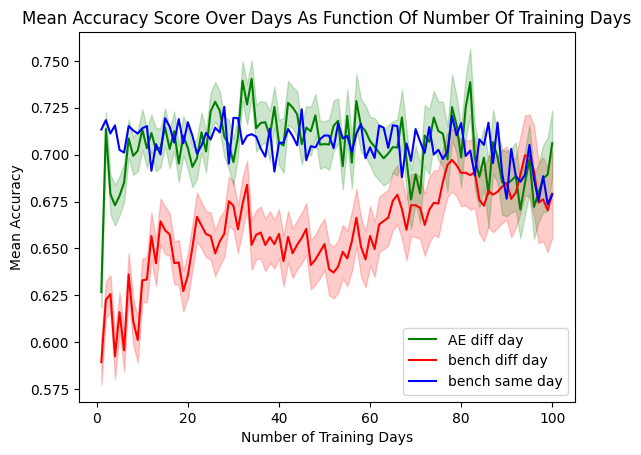

In [51]:
x_ax = range(1,1+len(bench_same_day_score_mean))
# Plots Results
plt.plot(x_ax, AE_diff_day_score_mean, label='AE diff day', color='g')
plt.plot(x_ax, bench_diff_day_score_mean, label='bench diff day', color='r')
plt.plot(x_ax, bench_same_day_score_mean, label='bench same day', color='b')

# # Add error area
plt.fill_between(x_ax, bench_diff_day_score_mean-bench_std, bench_diff_day_score_mean+bench_std,
    alpha=0.2, edgecolor='r', facecolor='r')
plt.fill_between(x_ax, AE_diff_day_score_mean-AE_std, AE_diff_day_score_mean+AE_std,
    alpha=0.2, edgecolor='g', facecolor='g')

# Figure stuff
plt.title('Mean Accuracy Score Over Days As Function Of Number Of Training Days')
plt.xlabel('Number of Training Days')
plt.ylabel('Mean Accuracy')
plt.legend()
plt.show()